In [1]:
import numpy as np 
import pandas as pd
import textwrap
import random
import matplotlib.pyplot as plt
import matplotlib as mpl
import pickle
from matplotlib.patches import Patch
from scipy import stats
from ast import literal_eval
import warnings
warnings.filterwarnings('ignore')
import networkx as nx
import obonet
import time
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker, VPacker

In [2]:
# matplotlib setting
# Matplotlib settings for publication-quality plots
base_fontsize = 16
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})

In [3]:
def format_scientific(x):
    a = x.split('e')[0]
    b = int(x.split('e')[1])
    return a+'\\times'+'10^{'+f'{b:d}'+'}'

# Function to capitalize certain terms
def capitalize_special_terms(text, terms=["DNA", "RNA", "II"]):
    words = text.split()
    capitalized_words = [
        "-".join([part.upper() if part.upper() in terms else part for part in word.split("-")])
        for word in words
    ]
    return " ".join(capitalized_words)


In [4]:
url = 'http://purl.obolibrary.org/obo/go/go-basic.obo'
graph = obonet.read_obo(url)

id_to_name = {id_: data.get('name') for id_, data in graph.nodes(data=True)}
name_to_id = {data['name']: id_ for id_, data in graph.nodes(data=True) if 'name' in data}

In [5]:
df_molfunc = pd.read_pickle('molfunc.pkl')
molfunc = df_molfunc[df_molfunc['adj_pvalue']<=0.05].reset_index(drop=True)
# Sort by 'stats' column in ascending order
molfunc_sorted = molfunc.sort_values(by='effect_size', ascending=False).reset_index(drop=True)
print(f"#molfunc: {len(df_molfunc)}, #significant molfunc: {len(molfunc_sorted)}")
molfunc_sorted


#molfunc: 94, #significant molfunc: 42


,GO,ent_prob_GO_Yes,ent_prob_GO_No,effect_size,effect_size_se,effect_size_CI,stats,pvalue,adj_pvalue
0,GO:0001227,"[0.047, 0.009, 0.412, 0.003, 0.203, 0.055, 0.1...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.303954,0.0,"(0.26600558538184044, 0.26600558538184044)",-13.252207,3.791654e-35,7.128310e-34
1,GO:0000978,"[0.253, 0.004, 0.004, 0.25, 0.333, 0.081, 0.21...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.287124,0.0,"(0.3231562346997604, 0.3231562346997604)",-23.069105,1.110396e-106,1.043773e-104
2,GO:0000981,"[0.004, 0.25, 0.003, 0.125, 0.333, 0.004, 0.22...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.269367,0.0,"(0.28513883840945753, 0.28513883840945753)",-22.774373,2.934678e-105,1.379299e-103
3,GO:0000976,"[0.435, 0.0, 0.0, 0.025, 0.393, 0.084, 0.015, ...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.257936,0.0,"(0.26120950926477843, 0.26120950926477843)",-9.889292,2.917158e-21,2.742129e-20
4,GO:0000977,"[0.003, 0.125, 0.006, 0.081, 0.133, 0.01, 0.00...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.255101,0.0,"(0.2577828612428726, 0.2577828612428726)",-11.110233,2.381647e-26,3.198212e-25
5,GO:0003700,"[0.253, 0.004, 0.004, 0.25, 0.189, 0.047, 0.00...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.254886,0.0,"(0.23247479809539515, 0.23247479809539515)",-14.132295,1.356372e-41,4.249966e-40
6,GO:0001228,"[0.061, 0.063, 0.078, 0.005, 0.392, 0.0, 0.042...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.241213,0.0,"(0.23983648840050964, 0.23983648840050964)",-12.571028,8.400823e-34,1.316129e-32
7,GO:1990837,"[0.047, 0.009, 0.412, 0.006, 0.081, 0.069, 0.0...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.235693,0.0,"(0.24047722583175593, 0.24047722583175593)",-13.796606,2.968271e-40,6.975437e-39
8,GO:0043565,"[0.004, 0.223, 0.014, 0.012, 0.02, 0.138, 0.1,...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.200367,0.0,"(0.2236353311196531, 0.2236353311196531)",-8.351763,3.075928e-16,2.224132e-15
9,GO:0003712,"[0.007, 0.008, 0.787, 0.084, 0.015, 0.139, 0.0...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.196290,0.0,"(0.18457519202537087, 0.18457519202537087)",-5.012972,5.392724e-07,2.203983e-06


In [13]:
for idx, row in molfunc_sorted[np.abs(molfunc_sorted['effect_size'])>=0.14].iterrows():
    print(idx, row['GO'], row['effect_size'], id_to_name[row['GO']])

0 GO:0001227 0.3039541408008361 DNA-binding transcription repressor activity, RNA polymerase II-specific
1 GO:0000978 0.287124313106892 RNA polymerase II cis-regulatory region sequence-specific DNA binding
2 GO:0000981 0.2693671638650855 DNA-binding transcription factor activity, RNA polymerase II-specific
3 GO:0000976 0.2579363127077845 transcription cis-regulatory region binding
4 GO:0000977 0.25510088323474595 RNA polymerase II transcription regulatory region sequence-specific DNA binding
5 GO:0003700 0.2548860086387019 DNA-binding transcription factor activity
6 GO:0001228 0.24121348473440954 DNA-binding transcription activator activity, RNA polymerase II-specific
7 GO:1990837 0.23569341803981392 sequence-specific double-stranded DNA binding
8 GO:0043565 0.2003669143074921 sequence-specific DNA binding
9 GO:0003712 0.1962895912921462 transcription coregulator activity
10 GO:0008013 0.18315612405040851 beta-catenin binding
11 GO:0003713 0.16257492453268604 transcription coactivator 

In [6]:
df_bioproc = pd.read_pickle('bioproc.pkl')
# df_bioproc[df_bioproc['adj_pvalue']<=0.05]
bioproc = df_bioproc[df_bioproc['adj_pvalue']<=0.05].reset_index(drop=True)
# Sort by 'stats' column in ascending order
bioproc_sorted = bioproc.sort_values(by='effect_size', ascending=False).reset_index(drop=True)
print(f"#Biological Process: {len(df_bioproc)}, #significant Biological Process: {len(bioproc_sorted)}")
bioproc_sorted


#Biological Process: 113, #significant Biological Process: 56


,GO,ent_prob_GO_Yes,ent_prob_GO_No,effect_size,effect_size_se,effect_size_CI,stats,pvalue,adj_pvalue
0,GO:0006357,"[0.253, 0.004, 0.004, 0.25, 0.003, 0.125, 0.33...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.258880,0.0,"(0.2462728315654021, 0.2462728315654021)",-23.177695,2.314480e-110,2.615363e-108
1,GO:0006325,"[0.0, 0.256, 0.0, 0.001, 0.393, 0.006, 0.007, ...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.196093,0.0,"(0.18425467747629307, 0.18425467747629307)",-5.120920,3.099217e-07,2.060068e-06
2,GO:0000122,"[0.134, 0.047, 0.009, 0.412, 0.022, 0.136, 0.1...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.182531,0.0,"(0.1751039041592268, 0.1751039041592268)",-12.190266,4.024385e-33,1.515852e-31
3,GO:0045944,"[0.047, 0.009, 0.412, 0.007, 0.008, 0.2, 0.161...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.174721,0.0,"(0.18109636483355204, 0.18109636483355204)",-12.887620,5.596139e-37,3.161818e-35
4,GO:0000398,"[0.004, 0.115, 0.552, 0.105, 0.029, 0.025, 0.0...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.162386,0.0,"(0.19634753571452093, 0.19634753571452093)",-4.572944,3.799544e-06,2.146743e-05
5,GO:0007010,"[0.0, 0.111, 0.131, 0.131, 0.033, 0.493, 0.001...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.161775,0.0,"(0.15942233524816107, 0.15942233524816107)",-4.249610,1.521301e-05,5.730233e-05
6,GO:0045893,"[0.003, 0.203, 0.004, 0.159, 0.256, 0.0, 0.001...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.161634,0.0,"(0.19323603388779806, 0.19323603388779806)",-9.152616,1.215847e-19,3.434767e-18
7,GO:0009653,"[0.081, 0.143, 0.08, 0.22, 0.005, 0.007, 0.001...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.160669,0.0,"(0.10246023591764779, 0.10246023591764779)",-4.465259,6.331741e-06,3.110812e-05
8,GO:0006355,"[0.189, 0.186, 0.001, 0.235, 0.131, 0.186, 0.0...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.160279,0.0,"(0.14257864283597685, 0.14257864283597685)",-8.347720,1.124859e-16,1.815844e-15
9,GO:0006366,"[0.004, 0.159, 0.055, 0.392, 0.002, 0.08, 0.0,...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.155319,0.0,"(0.15010685365724002, 0.15010685365724002)",-5.114414,2.572128e-07,1.937670e-06


In [16]:
for idx, row in bioproc_sorted[np.abs(bioproc_sorted['effect_size'])>=0.14].iterrows():
    print(idx, row['GO'], row['effect_size'], id_to_name[row['GO']])

0 GO:0006357 0.2588797607016682 regulation of transcription by RNA polymerase II
1 GO:0006325 0.1960932269412896 chromatin organization
2 GO:0000122 0.1825311692176217 negative regulation of transcription by RNA polymerase II
3 GO:0045944 0.174721040365744 positive regulation of transcription by RNA polymerase II
4 GO:0000398 0.16238633294992752 mRNA splicing, via spliceosome
5 GO:0007010 0.16177513850186523 cytoskeleton organization
6 GO:0045893 0.16163370453130022 positive regulation of DNA-templated transcription
7 GO:0009653 0.1606694824600774 anatomical structure morphogenesis
8 GO:0006355 0.1602788894173765 regulation of DNA-templated transcription
9 GO:0006366 0.15531947573105614 transcription by RNA polymerase II
10 GO:0008380 0.1459366814259311 RNA splicing
45 GO:0043410 -0.14006342633069646 positive regulation of MAPK cascade
46 GO:0045087 -0.14034918117036796 innate immune response
47 GO:0043161 -0.1565887610592747 proteasome-mediated ubiquitin-dependent protein catabolic pr

In [7]:
df_cellcom = pd.read_pickle('cellcom.pkl')
# df_bioproc = pd.read_pickle('bioproc.pkl')
# df_bioproc[df_bioproc['adj_pvalue']<=0.05]
cellcom = df_cellcom[df_cellcom['adj_pvalue']<=0.05].reset_index(drop=True)
# Sort by 'stats' column in ascending order
cellcom_sorted = cellcom.sort_values(by='effect_size', ascending=False).reset_index(drop=True)
print(f"#Cellular Component: {len(df_cellcom)}, #significant Cellular Component: {len(cellcom_sorted)}")
cellcom_sorted

#Cellular Component: 96, #significant Cellular Component: 61


,GO,ent_prob_GO_Yes,ent_prob_GO_No,effect_size,effect_size_se,effect_size_CI,stats,pvalue,adj_pvalue
0,GO:0000785,"[0.004, 0.25, 0.047, 0.009, 0.412, 0.006, 0.08...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.196030,0.0,"(0.20559964273720654, 0.20559964273720654)",-15.792013,6.130236e-54,1.961675e-52
1,GO:0005667,"[0.057, 0.055, 0.131, 0.078, 0.093, 0.0, 0.174...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.162793,0.0,"(0.18917249527373303, 0.18917249527373303)",-5.617624,1.854709e-08,8.093276e-08
2,GO:0016607,"[0.063, 0.026, 0.004, 0.256, 0.0, 0.001, 0.393...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.147233,0.0,"(0.1630538583007948, 0.1630538583007948)",-6.596205,4.066648e-11,2.076055e-10
3,GO:0016604,"[0.205, 0.046, 0.029, 0.001, 0.002, 0.393, 0.0...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",0.140939,0.0,"(0.13850420399779914, 0.13850420399779914)",-5.742474,7.370046e-09,3.369164e-08
4,GO:0005634,"[0.001, 0.498, 0.235, 0.253, 0.004, 0.097, 0.0...","[0.0, 0.012, 0.094, 0.007, 0.444, 0.005, 0.038...",0.128876,0.0,"(0.1307015405491873, 0.1307015405491873)",-17.211437,4.283654e-66,4.112308e-64
...,...,...,...,...,...,...,...,...,...
56,GO:0016323,"[0.258, 0.0, 0.001, 0.0, 0.0, 0.008, 0.0, 0.00...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",-0.181051,0.0,"(-0.17092261414706908, -0.17092261414706908)",7.479518,1.647636e-13,1.054487e-12
57,GO:0005764,"[0.005, 0.205, 0.106, 0.002, 0.0, 0.0, 0.0, 0....","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",-0.195273,0.0,"(-0.20129083682779175, -0.20129083682779175)",6.690303,4.108859e-11,2.076055e-10
58,GO:0009897,"[0.001, 0.0, 0.0, 0.038, 0.001, 0.007, 0.0, 0....","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",-0.227091,0.0,"(-0.23562474985372986, -0.23562474985372986)",10.200598,6.790377e-23,6.518762e-22
59,GO:0005743,"[0.003, 0.02, 0.0, 0.0, 0.001, 0.001, 0.0, 0.0...","[0.001, 0.0, 0.012, 0.094, 0.007, 0.444, 0.005...",-0.252800,0.0,"(-0.23670108396544712, -0.23670108396544712)",10.443562,5.875779e-23,6.267498e-22


In [20]:
for idx, row in cellcom_sorted[np.abs(cellcom_sorted['effect_size'])>=0.14].iterrows():
# for idx, row in cellcom_sorted.iterrows():
    print(idx, row['GO'], row['effect_size'], id_to_name[row['GO']])

0 GO:0000785 0.19602960433751182 chromatin
1 GO:0005667 0.1627933467592372 transcription regulator complex
2 GO:0016607 0.14723313984361144 nuclear speck
3 GO:0016604 0.14093877732081875 nuclear body
46 GO:0042734 -0.14156818835566776 presynaptic membrane
47 GO:0005615 -0.14490605609683715 extracellular space
48 GO:0016324 -0.14747949858543147 apical plasma membrane
49 GO:0042383 -0.15009512559967855 sarcolemma
50 GO:0009986 -0.1516776624551537 cell surface
51 GO:0005768 -0.15445928615525858 endosome
52 GO:0005739 -0.16009642146694905 mitochondrion
53 GO:0005930 -0.1606386461521572 axoneme
54 GO:0005765 -0.16605331522567465 lysosomal membrane
55 GO:0005770 -0.17229705033078693 late endosome
56 GO:0016323 -0.1810509266882337 basolateral plasma membrane
57 GO:0005764 -0.19527278866192388 lysosome
58 GO:0009897 -0.22709106944640606 external side of plasma membrane
59 GO:0005743 -0.25280044347666564 mitochondrial inner membrane
60 GO:0005759 -0.3087048177237985 mitochondrial matrix


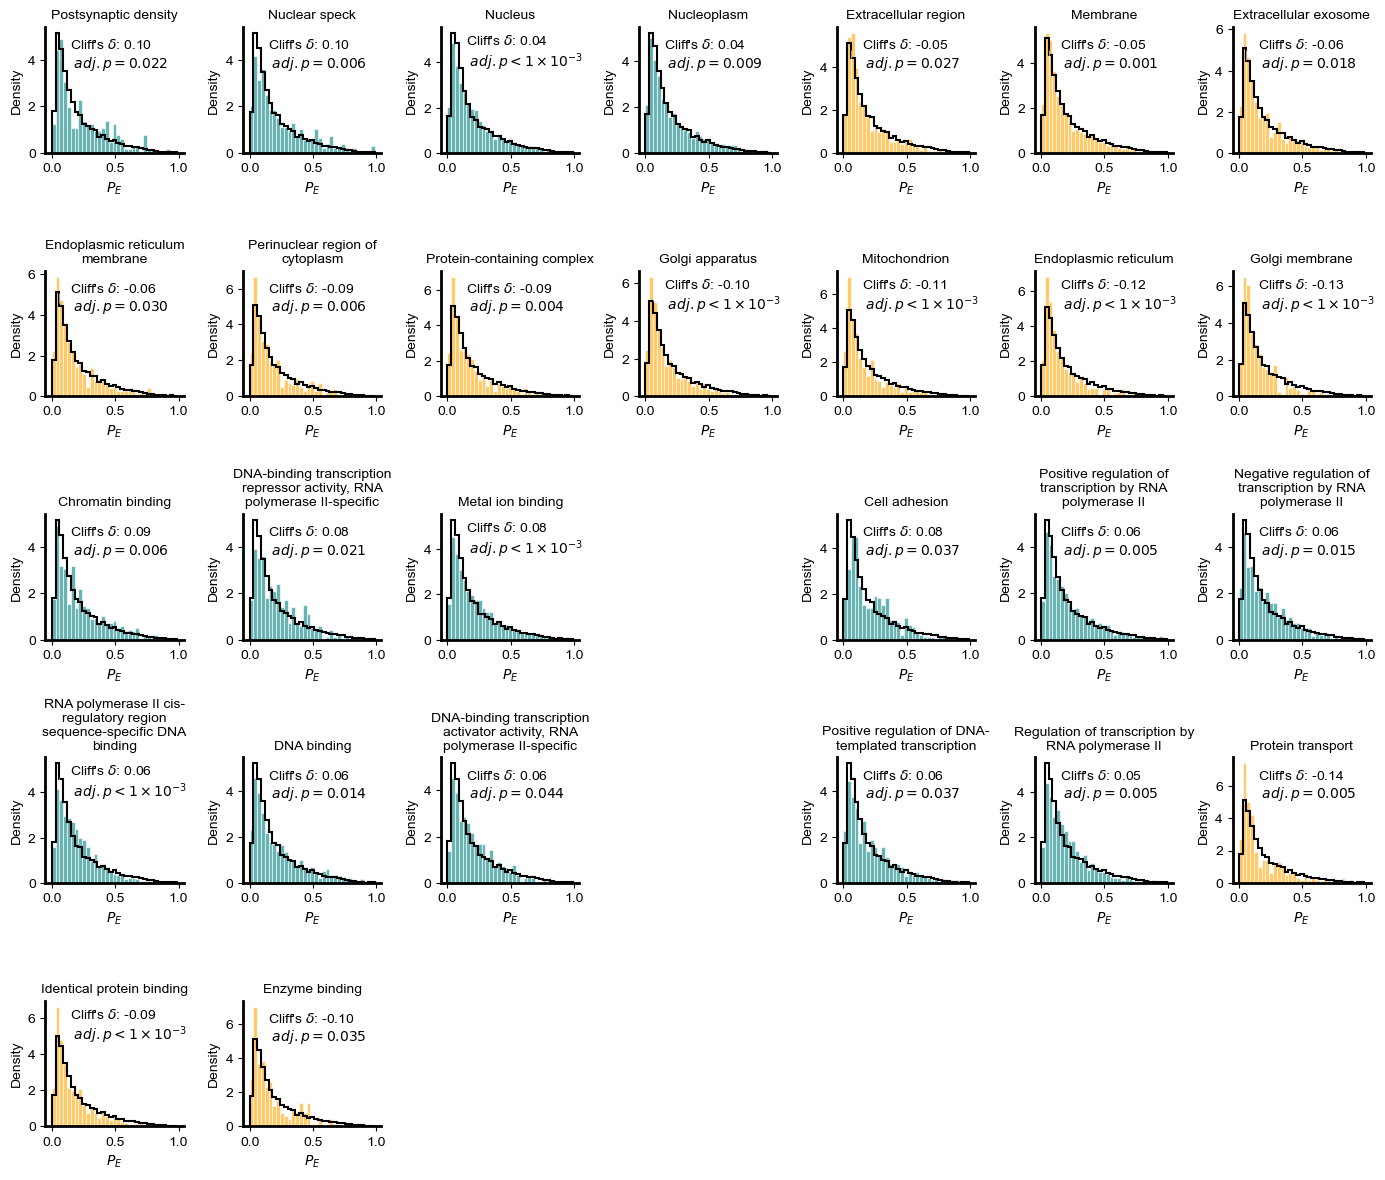

In [20]:
bin_width = .03
bins = np.arange(0, 1,bin_width)
x = bins[:-1]+bin_width/2.

# Create 3x3 subplots
fig, axes = plt.subplots(nrows=5, ncols=7, figsize=(14, 12))
axes = axes.flatten()
# Add titles for each category
# fig.text(0.6, 0.1, "Cellular Component", ha="center", fontsize=16, weight="bold")
# fig.text(0.6, 0.0, "Molecular Function", ha="center", fontsize=16, weight="bold")
# fig.text(0.6, -0.1, "Biological Process", ha="center", fontsize=16, weight="bold")

# cellcom
list_ax = list(range(0, 14))# + [16, 17]
# Plot each row
for idx, row in cellcom_sorted.iterrows():
    ax = axes[list_ax[idx]]
    h1 = np.histogram(row["ent_prob_GO_Yes"], bins=bins, density=True)[0]
    h2 = np.histogram(row["ent_prob_GO_No"], bins=bins, density=True)[0]
    
    eff_size =  row['effect_size']
    c = 'orange' if eff_size < 0 else 'teal' # if color is orange mean pE in this GO term less than PE in non-GO term
    eff_size_str = f"{eff_size:.2f}"
    # format p-value
    adj_p = row['adj_pvalue']
    adj_p_str = f"={adj_p:.3f}" if adj_p > 0.001 else "<1\\times10^{-3}"
    
    ax.bar(x, h1, alpha=0.6, width=bin_width, edgecolor='white', color=c, linewidth=0.8,
          label=f"Cliff's $\delta$: {eff_size_str} \n $adj. p {adj_p_str}$")
    hist = ax.hist(row["ent_prob_GO_No"], bins=bins, density=True, histtype='step', color='black', linewidth=1.5)
    
    go_term = str(id_to_name[row['GO']]).capitalize()
    go_term = capitalize_special_terms(go_term)  # Apply the capitalization function
    wrapped_go_term = "\n".join(textwrap.wrap(go_term, width=26))
    ax.set_title(f'{wrapped_go_term}', fontsize=10)
    ax.set_ylabel("Density")
    ax.set_xlabel(r"$P_{E}$")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
#     ax.legend()
    legend = ax.legend(handlelength=0,frameon=False,borderpad=0,loc=(.10,.64))
    legend.get_title().set_ha('center')   
#     ax.grid(True)

# Add vertical space between categories
plt.subplots_adjust(hspace=6.0)  # Adjust the value to increase/decrease spacing

# molfunc
list_ax = [14, 15, 16, 21, 22, 23, 28, 29]
# Plot each row
for idx, row in molfunc_sorted.iterrows():
    ax = axes[list_ax[idx]]
    h1 = np.histogram(row["ent_prob_GO_Yes"], bins=bins, density=True)[0]
    h2 = np.histogram(row["ent_prob_GO_No"], bins=bins, density=True)[0]
    eff_size =  row['effect_size']
    c = 'orange' if eff_size < 0 else 'teal' # if color is orange mean pE in this GO term less than PE in non-GO term
    eff_size_str = f"{eff_size:.2f}"
    # format p-value
    adj_p = row['adj_pvalue']
    adj_p_str = f"={adj_p:.3f}" if adj_p > 0.001 else "<1\\times10^{-3}"
    
    ax.bar(x, h1, alpha=0.6, width=bin_width, edgecolor='white', color=c, linewidth=0.8,
          label=f"Cliff's $\delta$: {eff_size_str} \n $adj. p {adj_p_str}$")
    hist = ax.hist(row["ent_prob_GO_No"], bins=bins, density=True, histtype='step', color='black', linewidth=1.5)
    
    go_term = str(id_to_name[row['GO']]).capitalize()
    go_term = capitalize_special_terms(go_term)  # Apply the capitalization function
    wrapped_go_term = "\n".join(textwrap.wrap(go_term, width=26))
    ax.set_title(f'{wrapped_go_term}', fontsize=10)

    ax.set_ylabel("Density")
    ax.set_xlabel(r"$P_{E}$")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
#     ax.legend()
    legend = ax.legend(handlelength=0,frameon=False,borderpad=0,loc=(.10,.64))
    legend.get_title().set_ha('center') 

# Add vertical space between categories
plt.subplots_adjust(hspace=6.0)  # Adjust the value to increase/decrease spacing

# bioproc
list_ax = [18, 19, 20, 25, 26, 27]
# Plot each row
for idx, row in bioproc_sorted.iterrows():
    ax = axes[list_ax[idx]]
    h1 = np.histogram(row["ent_prob_GO_Yes"], bins=bins, density=True)[0]
    h2 = np.histogram(row["ent_prob_GO_No"], bins=bins, density=True)[0]
    eff_size =  row['effect_size']
    c = 'orange' if eff_size < 0 else 'teal' # if color is orange mean pE in this GO term less than PE in non-GO term
    eff_size_str = f"{eff_size:.2f}"
    # format p-value
    adj_p = row['adj_pvalue']
    adj_p_str = f"={adj_p:.3f}" if adj_p > 0.001 else "<1\\times10^{-3}"
    
    ax.bar(x, h1, alpha=0.6, width=bin_width, edgecolor='white', color=c, linewidth=0.8,
          label=f"Cliff's $\delta$: {eff_size_str} \n $adj. p {adj_p_str}$")
    hist = ax.hist(row["ent_prob_GO_No"], bins=bins, density=True, histtype='step', color='black', linewidth=1.5)
    
    go_term = str(id_to_name[row['GO']]).capitalize()
    go_term = capitalize_special_terms(go_term)  # Apply the capitalization function
    wrapped_go_term = "\n".join(textwrap.wrap(go_term, width=30))
    ax.set_title(f'{wrapped_go_term}', fontsize=10)

    ax.set_ylabel("Density")
    ax.set_xlabel(r"$P_{E}$")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    
    legend = ax.legend(handlelength=0,frameon=False,borderpad=0,loc=(.10,.64))
    legend.get_title().set_ha('center')   
#     ax.grid(True)

# Remove empty subplots if any
list_to_del = [17, 24, 30, 31, 32, 33, 34]
for idx in list_to_del: #range(len(cellcom_sorted), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(f'GO_analysis.png', dpi=600, bbox_inches='tight')
# plt.savefig("GO_analysis.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [19]:
molfunc_sorted.to_pickle('molfunc_significant.pkl')
cellcom_sorted.to_pickle('cellcom_significant.pkl')
bioproc_sorted.to_pickle('bioproc_significant.pkl')

In [21]:
id_to_name

{'GO:0000001': 'mitochondrion inheritance',
 'GO:0000002': 'mitochondrial genome maintenance',
 'GO:0000006': 'high-affinity zinc transmembrane transporter activity',
 'GO:0000007': 'low-affinity zinc ion transmembrane transporter activity',
 'GO:0000009': 'alpha-1,6-mannosyltransferase activity',
 'GO:0000010': 'heptaprenyl diphosphate synthase activity',
 'GO:0000011': 'vacuole inheritance',
 'GO:0000012': 'single strand break repair',
 'GO:0000014': 'single-stranded DNA endodeoxyribonuclease activity',
 'GO:0000015': 'phosphopyruvate hydratase complex',
 'GO:0000016': 'lactase activity',
 'GO:0000017': 'alpha-glucoside transport',
 'GO:0000018': 'regulation of DNA recombination',
 'GO:0000019': 'regulation of mitotic recombination',
 'GO:0000022': 'mitotic spindle elongation',
 'GO:0000023': 'maltose metabolic process',
 'GO:0000024': 'maltose biosynthetic process',
 'GO:0000025': 'maltose catabolic process',
 'GO:0000026': 'alpha-1,2-mannosyltransferase activity',
 'GO:0000027': 'r

In [22]:
# save id_to_name to file for use later:
import pickle

In [23]:
with open('go_terms.pkl', 'wb') as f:
    pickle.dump(id_to_name, f)

In [24]:
with open('go_terms.pkl', 'rb') as f:
    go_terms_loaded = pickle.load(f)

In [25]:
go_terms_loaded

{'GO:0000001': 'mitochondrion inheritance',
 'GO:0000002': 'mitochondrial genome maintenance',
 'GO:0000006': 'high-affinity zinc transmembrane transporter activity',
 'GO:0000007': 'low-affinity zinc ion transmembrane transporter activity',
 'GO:0000009': 'alpha-1,6-mannosyltransferase activity',
 'GO:0000010': 'heptaprenyl diphosphate synthase activity',
 'GO:0000011': 'vacuole inheritance',
 'GO:0000012': 'single strand break repair',
 'GO:0000014': 'single-stranded DNA endodeoxyribonuclease activity',
 'GO:0000015': 'phosphopyruvate hydratase complex',
 'GO:0000016': 'lactase activity',
 'GO:0000017': 'alpha-glucoside transport',
 'GO:0000018': 'regulation of DNA recombination',
 'GO:0000019': 'regulation of mitotic recombination',
 'GO:0000022': 'mitotic spindle elongation',
 'GO:0000023': 'maltose metabolic process',
 'GO:0000024': 'maltose biosynthetic process',
 'GO:0000025': 'maltose catabolic process',
 'GO:0000026': 'alpha-1,2-mannosyltransferase activity',
 'GO:0000027': 'r